## FEATURE ENGINEERING

## TRAIN TEST SPLIT

In [1]:
import pandas as pd, numpy as np, seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split

In [3]:
from pydataset import data

In [4]:
iris = data('iris')

In [5]:
iris.head()

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
1,5.1,3.5,1.4,0.2,setosa
2,4.9,3.0,1.4,0.2,setosa
3,4.7,3.2,1.3,0.2,setosa
4,4.6,3.1,1.5,0.2,setosa
5,5.0,3.6,1.4,0.2,setosa


#### Seperate X and Y variables from iris

In [6]:
y = iris['Species']

In [7]:
y.head()

1    setosa
2    setosa
3    setosa
4    setosa
5    setosa
Name: Species, dtype: object

In [8]:
X = iris.drop('Species',axis = 1)

In [9]:
X.head()

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
1,5.1,3.5,1.4,0.2
2,4.9,3.0,1.4,0.2
3,4.7,3.2,1.3,0.2
4,4.6,3.1,1.5,0.2
5,5.0,3.6,1.4,0.2


#### Train Test Split

In [10]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.3,random_state = 10)

In [11]:
X_train.shape, X_test.shape

((105, 4), (45, 4))

In [12]:
y_train.shape, y_test.shape

((105,), (45,))

## SCALING THE DATA

In [13]:
iris.describe()

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [14]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

## MINMAXSCALER

In [15]:
scale = MinMaxScaler()

In [16]:
scaled_train = scale.fit_transform(X_train)

In [17]:
scaled_train.shape

(105, 4)

## STANDARD SCALER

In [18]:
standard = StandardScaler()

In [19]:
scaled_train_standard = standard.fit_transform(X_train)

In [20]:
scaled_train_standard.shape

(105, 4)

## Encoding Categorical variables

In [21]:
from sklearn.preprocessing import LabelEncoder

#### ENCODING SPECIES COLUMN IN IRIS DATA

In [22]:
encode = LabelEncoder()

In [23]:
encode.fit_transform(iris['Species'])

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [24]:
iris['Species'].head()

1    setosa
2    setosa
3    setosa
4    setosa
5    setosa
Name: Species, dtype: object

## BINNING THE NUMERIC VARIABLES

In [25]:
iris['Sepal.Length'].describe()

count    150.000000
mean       5.843333
std        0.828066
min        4.300000
25%        5.100000
50%        5.800000
75%        6.400000
max        7.900000
Name: Sepal.Length, dtype: float64

#### CREATE BINS WITH PANDAS CUT

In [26]:
bins = pd.cut(iris['Sepal.Length'],bins = [4,6,8])

<AxesSubplot:>

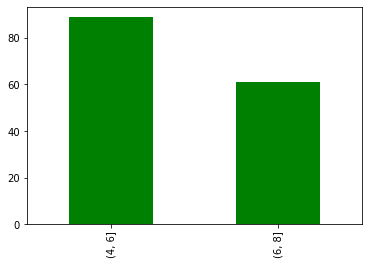

In [27]:
pd.value_counts(bins).plot(kind = 'bar',color = 'Green')

<AxesSubplot:ylabel='Sepal.Length'>

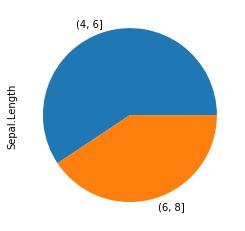

In [28]:
pd.value_counts(bins).plot(kind = 'pie')

### CREATING DUMMY VARIABLES

In [29]:
pd.get_dummies(iris['Species'])

,setosa,versicolor,virginica
1,1,0,0
2,1,0,0
3,1,0,0
4,1,0,0
5,1,0,0
6,1,0,0
7,1,0,0
8,1,0,0
9,1,0,0
10,1,0,0


## DIMENSIONALITY REDUCTION: PRINCIPLE COMPONENT ANALYSIS

In [30]:
iris = data('iris')

In [31]:
iris = iris.drop('Species',axis = 1)

In [32]:
iris.head()

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
1,5.1,3.5,1.4,0.2
2,4.9,3.0,1.4,0.2
3,4.7,3.2,1.3,0.2
4,4.6,3.1,1.5,0.2
5,5.0,3.6,1.4,0.2


### SCALING THE DATA USING STANDARD SACLAR

In [33]:
from sklearn.preprocessing import StandardScaler

In [34]:
scale = StandardScaler()

In [35]:
fit = scale.fit(iris)

In [36]:
fit.var_

array([0.68112222, 0.18871289, 3.09550267, 0.57713289])

In [37]:
from sklearn.decomposition import PCA

In [38]:
PCA_out = PCA(n_components=2)

In [39]:
new_data = PCA_out.fit_transform(iris)

### CONVERTING PCA INTO A DATAFRAME

In [40]:
after_pca = pd.DataFrame(new_data,columns = ['PC1','PC2'])

In [41]:
iris.head()

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
1,5.1,3.5,1.4,0.2
2,4.9,3.0,1.4,0.2
3,4.7,3.2,1.3,0.2
4,4.6,3.1,1.5,0.2
5,5.0,3.6,1.4,0.2


In [42]:
after_pca.head()

,PC1,PC2
0,-2.684126,0.319397
1,-2.714142,-0.177001
2,-2.888991,-0.144949
3,-2.745343,-0.318299
4,-2.728717,0.326755


## SUBSET SELECTION

### SELECT K BEST METHOD

#### SPLIT THE DATA

In [43]:
mtcars = data('mtcars')

In [44]:
mtcars.head()

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2


In [46]:
mtcars.columns

Index(['mpg', 'cyl', 'disp', 'hp', 'drat', 'wt', 'qsec', 'vs', 'am', 'gear',
       'carb'],
      dtype='object')

In [47]:
mtcars.shape

(32, 11)

In [48]:
mtcars.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32 entries, Mazda RX4 to Volvo 142E
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   mpg     32 non-null     float64
 1   cyl     32 non-null     int64  
 2   disp    32 non-null     float64
 3   hp      32 non-null     int64  
 4   drat    32 non-null     float64
 5   wt      32 non-null     float64
 6   qsec    32 non-null     float64
 7   vs      32 non-null     int64  
 8   am      32 non-null     int64  
 9   gear    32 non-null     int64  
 10  carb    32 non-null     int64  
dtypes: float64(5), int64(6)
memory usage: 3.0+ KB


In [49]:
mtcars.describe()

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
count,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.0000
mean,20.090625,6.187500,230.721875,146.687500,3.596563,3.217250,17.848750,0.437500,0.406250,3.687500,2.8125
std,6.026948,1.785922,123.938694,68.562868,0.534679,0.978457,1.786943,0.504016,0.498991,0.737804,1.6152
min,10.400000,4.000000,71.100000,52.000000,2.760000,1.513000,14.500000,0.000000,0.000000,3.000000,1.0000
25%,15.425000,4.000000,120.825000,96.500000,3.080000,2.581250,16.892500,0.000000,0.000000,3.000000,2.0000
50%,19.200000,6.000000,196.300000,123.000000,3.695000,3.325000,17.710000,0.000000,0.000000,4.000000,2.0000
75%,22.800000,8.000000,326.000000,180.000000,3.920000,3.610000,18.900000,1.000000,1.000000,4.000000,4.0000
max,33.900000,8.000000,472.000000,335.000000,4.930000,5.424000,22.900000,1.000000,1.000000,5.000000,8.0000


In [50]:
Y = mtcars['mpg']

In [52]:
X = mtcars.drop('mpg',axis = 1)

In [54]:
X.columns

Index(['cyl', 'disp', 'hp', 'drat', 'wt', 'qsec', 'vs', 'am', 'gear', 'carb'], dtype='object')

In [55]:
X.shape

(32, 10)

In [56]:
Y.shape

(32,)

#### INSTANTIATE THE ALGORITHM

In [60]:
from sklearn.feature_selection import SelectKBest

In [61]:
features = SelectKBest()

In [64]:
fit = features.fit(X,Y)

In [65]:
fit.scores_

array([ 6.91796875,  3.40360704, 11.1494294 ,  1.36088832, 13.37387624,
        2.10174982,  4.30208333,  1.95963542,  2.98958333,  6.44791667])

In [70]:
#features.fit_transform(X,Y)

In [68]:
fit = SelectKBest(k=5)

In [69]:
fit.fit_transform(X,Y)

array([[  6.   , 110.   ,   2.62 ,   0.   ,   4.   ],
       [  6.   , 110.   ,   2.875,   0.   ,   4.   ],
       [  4.   ,  93.   ,   2.32 ,   1.   ,   1.   ],
       [  6.   , 110.   ,   3.215,   1.   ,   1.   ],
       [  8.   , 175.   ,   3.44 ,   0.   ,   2.   ],
       [  6.   , 105.   ,   3.46 ,   1.   ,   1.   ],
       [  8.   , 245.   ,   3.57 ,   0.   ,   4.   ],
       [  4.   ,  62.   ,   3.19 ,   1.   ,   2.   ],
       [  4.   ,  95.   ,   3.15 ,   1.   ,   2.   ],
       [  6.   , 123.   ,   3.44 ,   1.   ,   4.   ],
       [  6.   , 123.   ,   3.44 ,   1.   ,   4.   ],
       [  8.   , 180.   ,   4.07 ,   0.   ,   3.   ],
       [  8.   , 180.   ,   3.73 ,   0.   ,   3.   ],
       [  8.   , 180.   ,   3.78 ,   0.   ,   3.   ],
       [  8.   , 205.   ,   5.25 ,   0.   ,   4.   ],
       [  8.   , 215.   ,   5.424,   0.   ,   4.   ],
       [  8.   , 230.   ,   5.345,   0.   ,   4.   ],
       [  4.   ,  66.   ,   2.2  ,   1.   ,   1.   ],
       [  4.   ,  52.   ,   